In [40]:
#Libraries import

#Data processing and preparation
import numpy as np
import pandas as pd
import datetime
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

#Models

from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as imbpipeline

#Other
import time
import warnings
warnings.filterwarnings("ignore")


## 1. Data Import

In [41]:
#Import both dataset given and look at their shapes
bank = pd.read_csv('bank_marketing/bank.csv', sep=";") # reading the first CSV file and displaying the top five rows
bank_full = pd.read_csv('bank_marketing/bank-full.csv', sep=";") # reading the first CSV file and displaying the top five rows
bank_full.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [42]:
bank_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


Overall, the dataset consists of 45211 entries and has 16 explaining variables and no missing variables, no duplicates. Since the names of the columns are not self-explanatory it makes sense to rename them.

In [43]:
# Rename columns so it will be easier to understand them while processing
bank_full_v2=bank_full.rename(columns={'job':'job_type', 'marital':'marital_status','education':'education_level',
                         'default':'credit_default','housing':'housing_loan','loan':'personal_loan',
                         'contact':'contact_type','day':'last_contact_day','month':'last_contact_month',
                         'duration':'last_contact_duration','campaign':'contacts_curr_campaign',
                         'pdays':'days_since_prev_camp_contact','previous':'contacts_prev_campaign',
                         'poutcome':'prev_outcome','y':'y_curr_outcome'})
bank_full_v2.columns

Index(['age', 'job_type', 'marital_status', 'education_level',
       'credit_default', 'balance', 'housing_loan', 'personal_loan',
       'contact_type', 'last_contact_day', 'last_contact_month',
       'last_contact_duration', 'contacts_curr_campaign',
       'days_since_prev_camp_contact', 'contacts_prev_campaign',
       'prev_outcome', 'y_curr_outcome'],
      dtype='object')

In [44]:
#Perform check if there are any duplicates in data
len(bank_full_v2)- len(bank_full_v2.drop_duplicates ())

0

## Target variable analysis

In [45]:
bank_full_v2['y_curr_outcome'].value_counts()

y_curr_outcome
no     39922
yes     5289
Name: count, dtype: int64

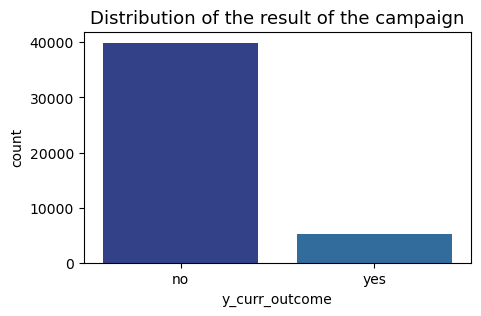

In [46]:
#Plot distribution of the target variable
plt.figure(figsize=(5, 3))  # Set the figure size

# Create the countplot with title
sns.countplot(data=bank_full_v2, x= 'y_curr_outcome', palette=reversed_palette)  # Change palette for colors
plt.title("Distribution of the result of the campaign", fontsize=13)  # Set the title

# Show the plot
plt.show()

## Data Exploration and preprocessing

### Numerical variables

#### Distributions

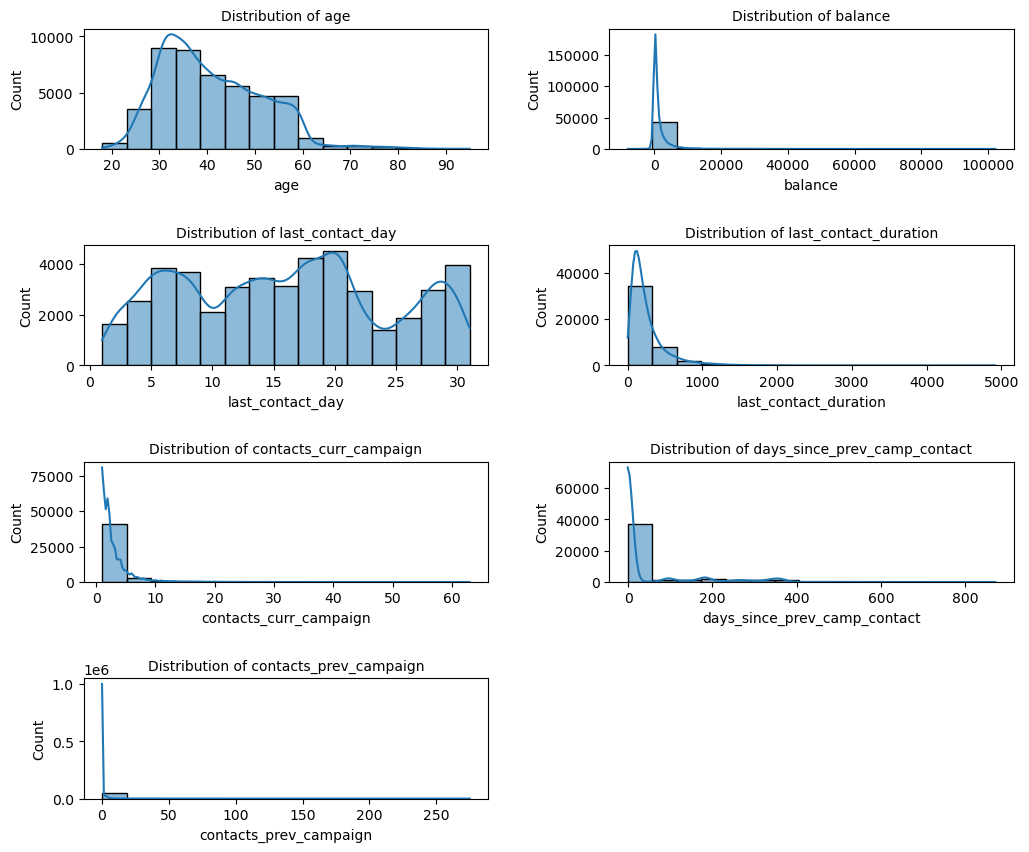

In [47]:
#Numerical variables distributions

# Get a list of integer columns from the DataFrame
int_columns = bank_full_v2.select_dtypes(include=['int64']).columns

# Create the subplot grid
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 10))
plt.subplots_adjust(wspace=0.3, hspace=0.8)

# Iterate through the integer columns and plot the distributions
for i, column in enumerate(int_columns):
    row, col = divmod(i, 2)
    ax = axes[row, col]
    sns.histplot(data=bank_full_v2, x=column, kde=True,  ax=ax, bins = 15)
    ax.set_title(f"Distribution of {column}", fontsize=10)


# Remove any unused subplots
if i < (4 * 2 - 1):
    for j in range(i + 1, 4 * 2):
        fig.delaxes(axes[divmod(j, 2)])

plt.show()

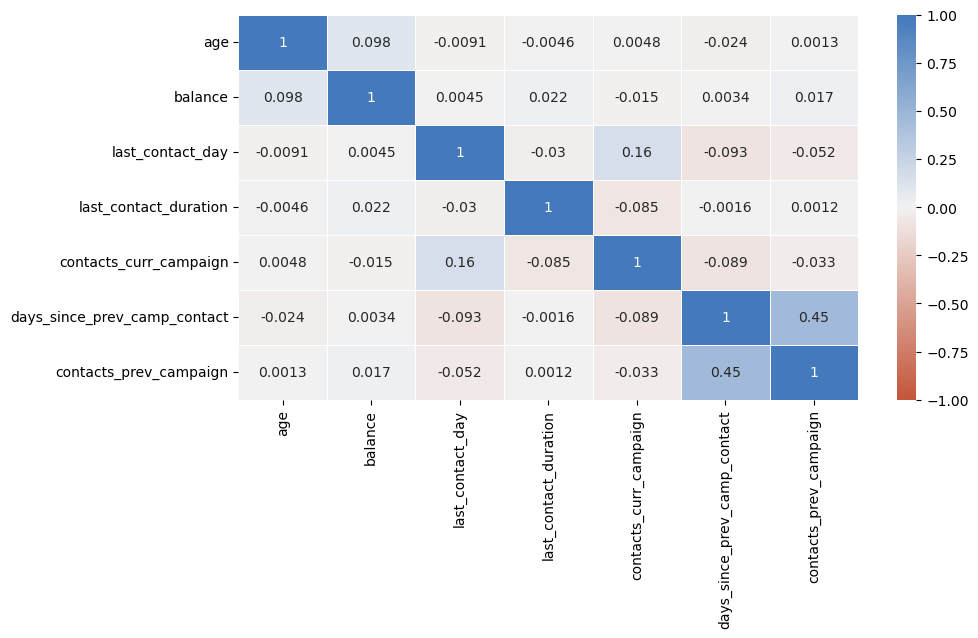

In [48]:
#Calculate correlations for numeric variables

numerical = bank_full_v2.select_dtypes(['int64', 'float64']).columns.to_list()
fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(bank_full_v2[numerical].corr(), vmin=-1, vmax=1, cmap=sns.diverging_palette(20, 250, as_cmap=True), annot=True, linewidths=.5)
plt.show()

Since there is no highly correlated features we don't need to exclude variables from the analysis.

<Axes: title={'center': 'Distribution of balance'}, xlabel='balance', ylabel='Count'>

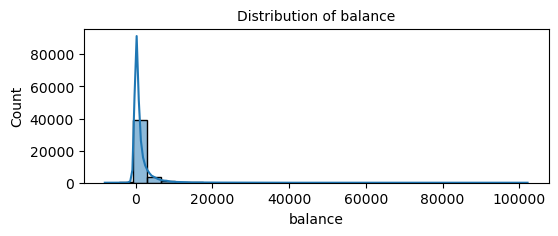

In [49]:
#Graph for the report - Skewness
plt.figure(figsize=(6, 2))
plt.title("Distribution of balance", fontsize=10)
sns.histplot(data=bank_full_v2, x="balance", kde=True, bins = 30)

Since we have some variables that contain huge instances it makes sense to apply scaling techniques to numerical variables

### Categorical variables

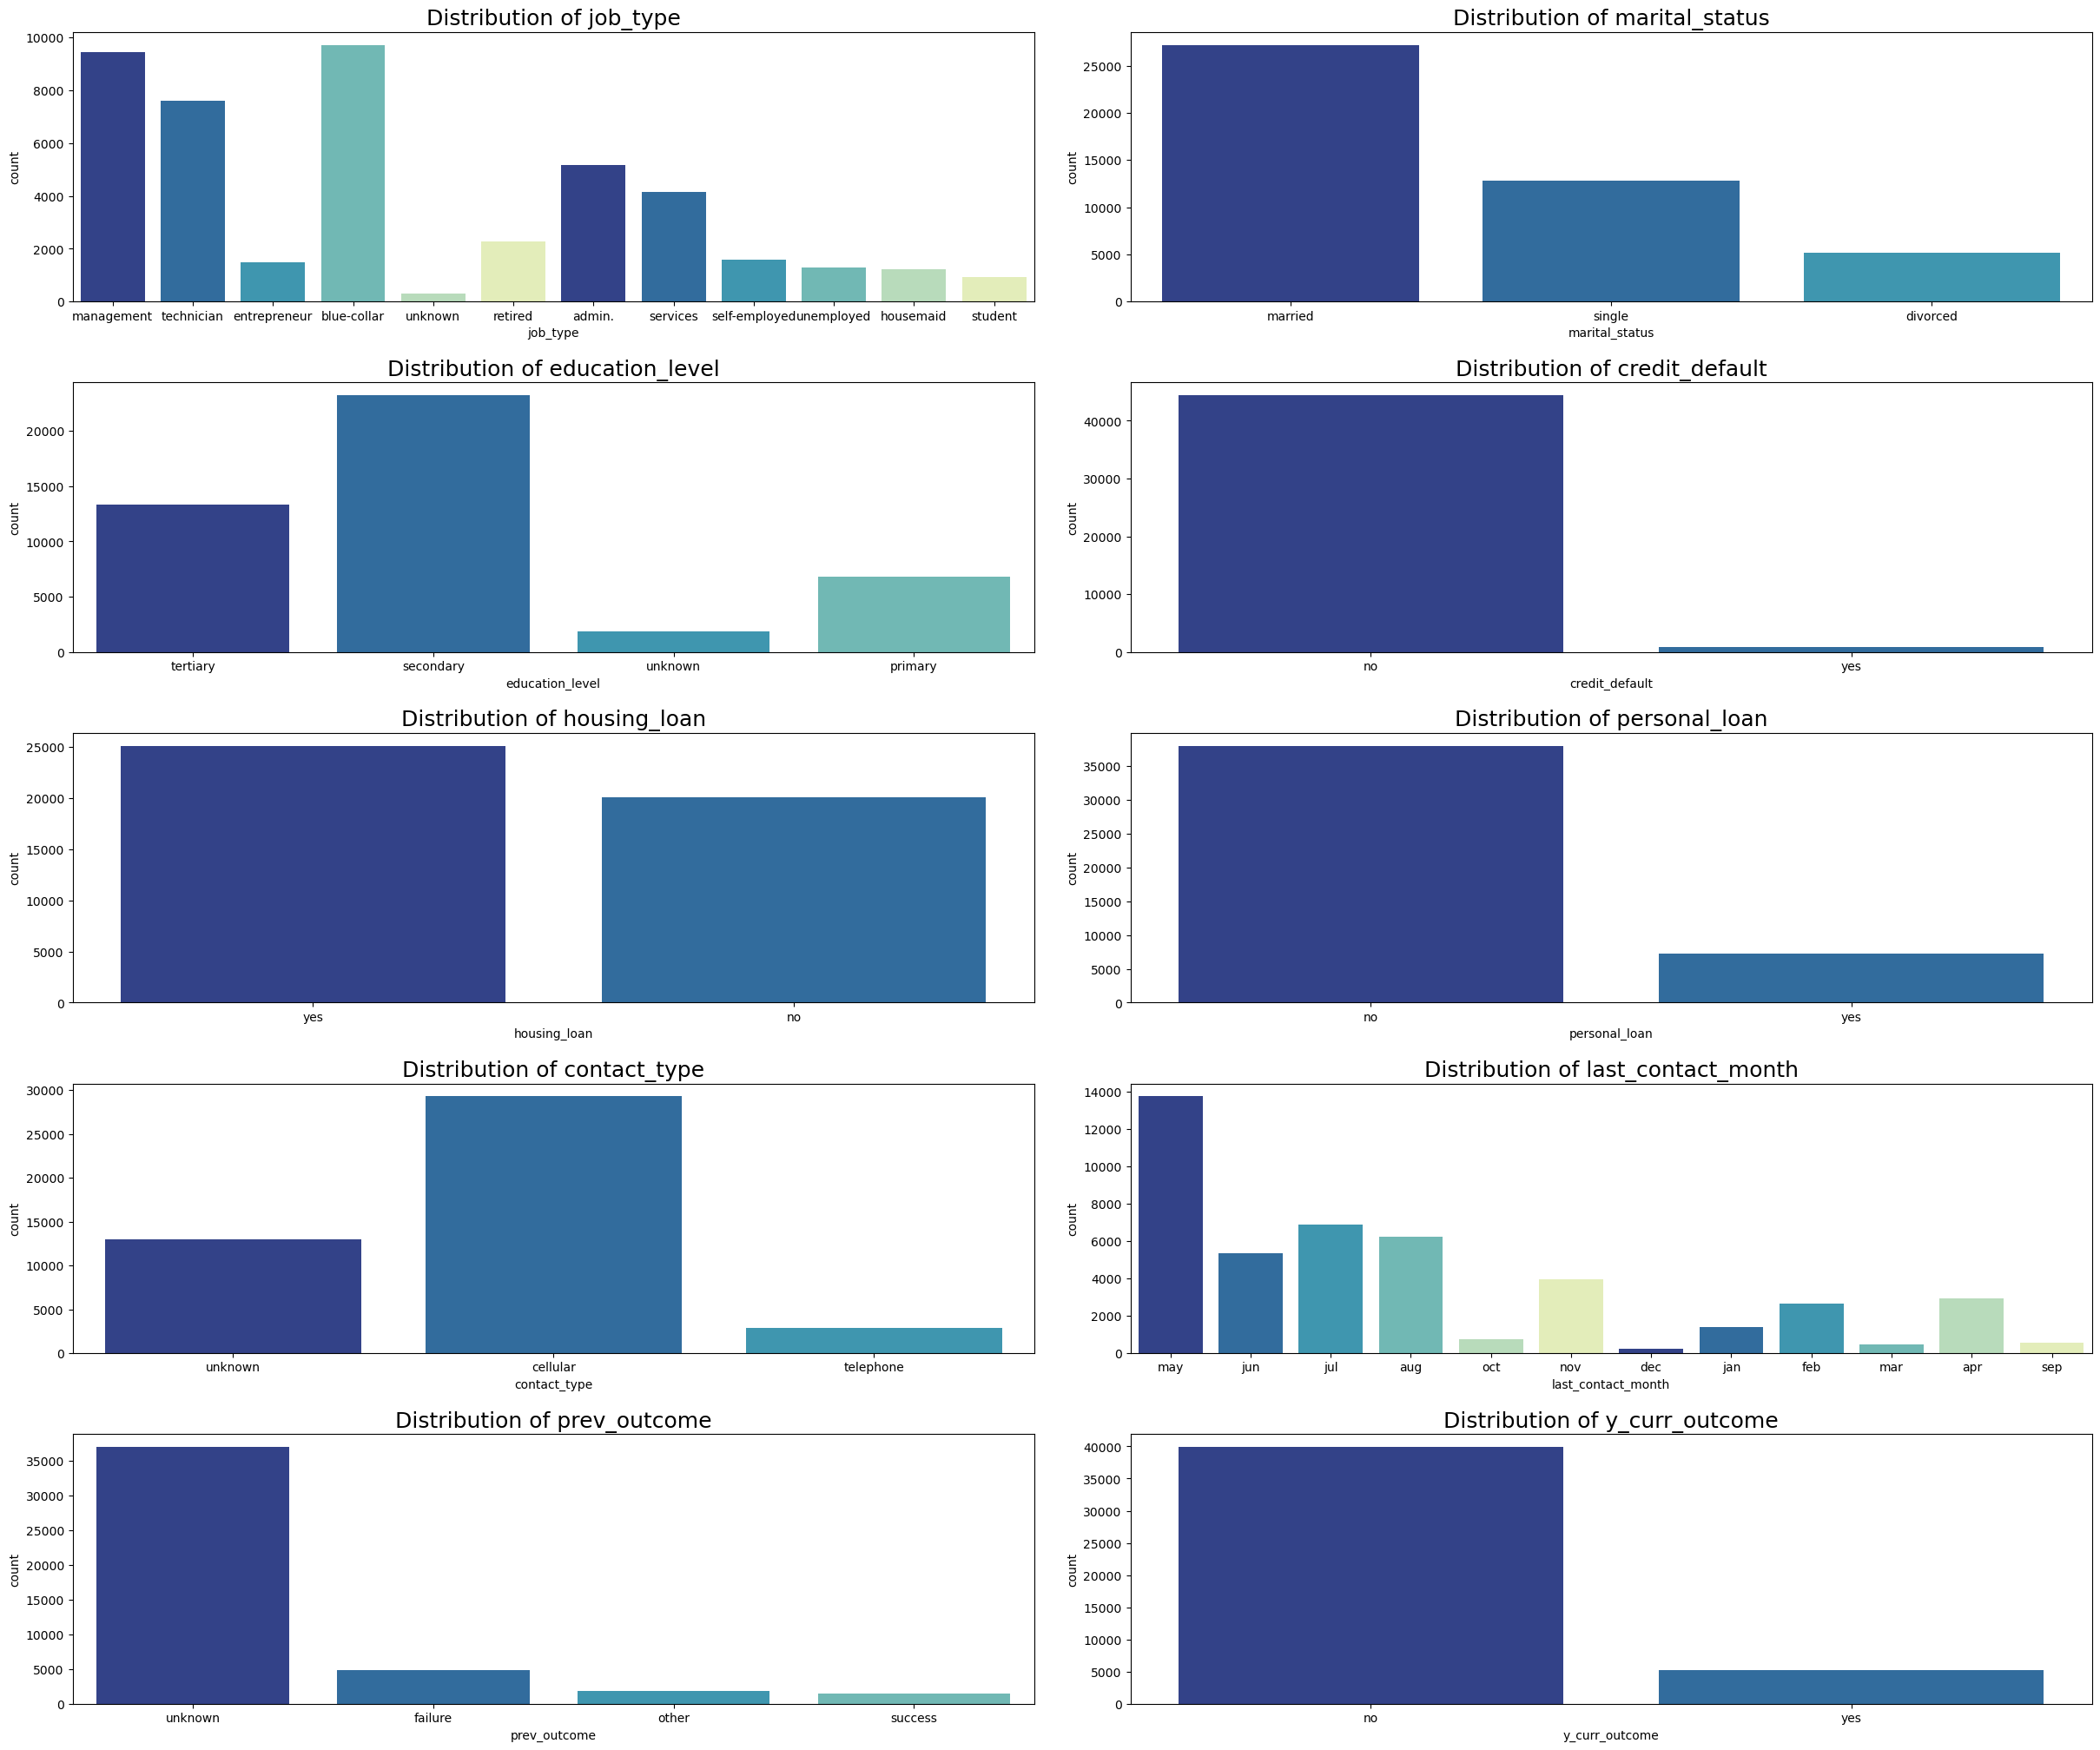

In [50]:
#Categorical variables distributions

# Get a list of categorical columns from the DataFrame
cat_columns = bank_full_v2.select_dtypes(include=['object']).columns

# Determine the number of rows and columns in the subplot grid
num_columns = 2  # Set the number of columns per row
num_plots = len(cat_columns)
num_rows = (num_plots + num_columns - 1) // num_columns

# Create the subplot grid
fig, axes = plt.subplots(nrows=num_rows, ncols=num_columns, figsize=(30, 25))
plt.subplots_adjust(wspace=0.1, hspace=0.3)

# Iterate through the categorical columns and plot the distributions
for i, column in enumerate(cat_columns):
    row, col = divmod(i, num_columns)
    ax = axes[row, col]
    sns.countplot(data=bank_full_v2, x=column, ax=ax, palette=reversed_palette)
    ax.set_title(f"Distribution of {column}", fontsize=18)

# Remove any unused subplots
if i < (num_rows * num_columns - 1):
    for j in range(i + 1, num_rows * num_columns):
        fig.delaxes(axes[divmod(j, num_columns)])

plt.show()


# Data Transformation

### Train test split

Perform train/test splitting before data preprocessing to be sure that information from the testing set doesn't influence the preprocessing.

In [51]:
X = bank_full_v2.drop('y_curr_outcome', axis=1)
y = bank_full_v2['y_curr_outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Numerical variables transformation - Outliers

In [52]:
#Function for strong outliers detection

def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit


#Function for outliers imputation

def impute_outliers(dataframe_calc, dataframe_inpt, col_name):
    lower_bound, upper_bound = outlier_thresholds(dataframe_calc, col_name)
    dataframe_inpt[col_name] = dataframe_inpt[col_name].apply(lambda x: min(x, upper_bound))

In [53]:
X_train['days_since_prev_camp_contact'] = X_train['days_since_prev_camp_contact'].apply(lambda x: 0 if x == -1 else 1)
X_test['days_since_prev_camp_contact'] = X_test['days_since_prev_camp_contact'].apply(lambda x: 0 if x == -1 else 1)

In [54]:
columns_with_potential_outliers = ['last_contact_duration', 'contacts_curr_campaign', 'contacts_prev_campaign']

for i in columns_with_potential_outliers:
    print(f"Upper and Lower limits for {i}:", outlier_thresholds(X_train, i))

Upper and Lower limits for last_contact_duration: (-1035.0499999999956, 1815.7499999999927)
Upper and Lower limits for contacts_curr_campaign: (-9.5, 18.5)
Upper and Lower limits for contacts_prev_campaign: (-6.0, 10.0)


Use outliers imputation function defined previously to process outliers

In [55]:
for i in columns_with_potential_outliers:
    impute_outliers(X_train, X_train, i)
    impute_outliers(X_train, X_test, i)

### Numerical variables transformation - Scaling

In [56]:
col_scaling = ["age", "balance", "last_contact_duration", "contacts_curr_campaign", "contacts_prev_campaign"]

scaler = MinMaxScaler()

#Fit scaler using train data and then apply it to the train and test data

X_train_sc = X_train.copy()
X_test_sc = X_test.copy()

X_train_sc[col_scaling] = scaler.fit_transform(X_train_sc[col_scaling])
X_test_sc[col_scaling] = scaler.transform(X_test_sc[col_scaling])

### Categorical variables transformation - Encoding

In [57]:
def encoding_inplace(X_train, X_test):
    label_encoder = LabelEncoder()

    for column in X_train.columns:
        if X_train[column].dtype == 'object':

            X_train[column] = label_encoder.fit_transform(X_train[column])
            X_test[column] = label_encoder.transform(X_test[column])
    
    return X_train, X_test

In [58]:
#Perform label encoding
X_train, X_test = encoding_inplace(X_train, X_test)
X_train_sc, X_test_sc = encoding_inplace(X_train_sc, X_test_sc)

# Convert binary labels to 0 and 1
y_train = y_train.apply(lambda x: 0 if x == "no" else 1)
y_test = y_test.apply(lambda x: 0 if x == "no" else 1)

In [66]:
# save datasets
X_train_sc.to_csv('bank_marketing_preprocessed/X_train.csv', index=False)
X_test_sc.to_csv('bank_marketing_preprocessed/X_validation.csv', index=False)

y_train.to_csv('bank_marketing_preprocessed/y_train.csv', index=False)
y_test.to_csv('bank_marketing_preprocessed/y_validation.csv', index=False)

In [68]:
X_train.shape
y_train

10747    0
26054    0
9125     0
41659    0
4443     0
        ..
11284    1
44732    0
38158    0
860      0
15795    0
Name: y_curr_outcome, Length: 31647, dtype: int64

### Oversampling

Since our dataset is highly imbalanced we need to apply oversampling technique to achive class balance. 

In [62]:
smote = SMOTE()  

x_train_os, y_train_os = smote.fit_resample(X_train, y_train)
print("----Non-scaled dataset----")
print("The number of Classes before fit {}".format(Counter(y_train)))
print("The number of Classes after fit {}".format(Counter(y_train_os)))

print("----Scaled dataset----")
x_train_os_sc, y_train_os_sc = smote.fit_resample(X_train_sc, y_train)
print("The number of Classes before fit {}".format(Counter(y_train)))
print("The number of Classes after fit {}".format(Counter(y_train_os)))

AttributeError: 'NoneType' object has no attribute 'split'